In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style("white")

# Renk paleti
BIST_BLUE = '#003087'
BIST_RED = '#e31937'
GRAY = '#666666'
GREEN = '#047857'

print("✅ Kütüphaneler hazır!")

✅ Kütüphaneler hazır!


In [2]:
# Tarkim BIST ticker: TARKM.IS
ticker = yf.Ticker("TARKM.IS")

# Finansal tablolar
income_stmt = ticker.financials
balance_sheet = ticker.balance_sheet
cash_flow = ticker.cashflow

print("📊 Mevcut veri satırları — Gelir Tablosu:")
print(income_stmt.index.tolist())
print("\n📊 Nakit Akış Tablosu:")
print(cash_flow.index.tolist())
print("\n📊 Bilanço:")
print(balance_sheet.index.tolist())

📊 Mevcut veri satırları — Gelir Tablosu:
['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Rent Expense Supplemental', 'Total Operating Income As Reported', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Net Income Common Stockholders', 'Otherunder Preferred Stock Dividend', 'Net Income', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Other Special Charges', 'Net Non Operating Interest Income Expense',

In [3]:
# Temel finansal verileri çek
revenue = income_stmt.loc['Total Revenue'].sort_index()
ebit = income_stmt.loc['EBIT'].sort_index()
da = cash_flow.loc['Depreciation And Amortization'].sort_index()
capex = cash_flow.loc['Capital Expenditure'].sort_index()
delta_wc = cash_flow.loc['Change In Working Capital'].sort_index()
net_debt = balance_sheet.loc['Net Debt'].sort_index()
shares = balance_sheet.loc['Share Issued'].sort_index()

# TRY milyon olarak göster
print("📊 Tarkim Finansalları (TRY Milyon):")
print("=" * 55)
print(f"\n💰 Revenue:\n{(revenue/1e6).round(1)}")
print(f"\n📈 EBIT:\n{(ebit/1e6).round(1)}")
print(f"\n🔧 D&A:\n{(da/1e6).round(1)}")
print(f"\n🏗️  CapEx:\n{(capex/1e6).round(1)}")
print(f"\n🔄 ΔWorking Capital:\n{(delta_wc/1e6).round(1)}")
print(f"\n💳 Net Debt:\n{(net_debt/1e6).round(1)}")
print(f"\n📋 Shares Outstanding:\n{(shares/1e6).round(2)} Milyon")

📊 Tarkim Finansalları (TRY Milyon):

💰 Revenue:
2021-12-31       NaN
2022-12-31    1393.0
2023-12-31    1436.9
2024-12-31    1839.4
2025-12-31    2039.7
Name: Total Revenue, dtype: float64

📈 EBIT:
2021-12-31      NaN
2022-12-31    337.4
2023-12-31    152.2
2024-12-31   -106.9
2025-12-31     54.0
Name: EBIT, dtype: float64

🔧 D&A:
2021-12-31     NaN
2022-12-31     9.6
2023-12-31    33.0
2024-12-31    47.8
2025-12-31    50.9
Name: Depreciation And Amortization, dtype: float64

🏗️  CapEx:
2021-12-31      NaN
2022-12-31   -171.6
2023-12-31   -162.2
2024-12-31   -378.3
2025-12-31   -913.8
Name: Capital Expenditure, dtype: float64

🔄 ΔWorking Capital:
2021-12-31      NaN
2022-12-31   -468.7
2023-12-31   -247.5
2024-12-31    293.4
2025-12-31    339.0
Name: Change In Working Capital, dtype: float64

💳 Net Debt:
2021-12-31    235.8
2022-12-31    616.5
2023-12-31      NaN
2024-12-31     76.0
2025-12-31    834.8
Name: Net Debt, dtype: float64

📋 Shares Outstanding:
2021-12-31     NaN
2022-12-31 

In [4]:
# Temiz veri seti (2022-2025)
df = pd.DataFrame({
    'Revenue': revenue,
    'EBIT': ebit,
    'DA': da,
    'CapEx': capex,
    'DeltaWC': delta_wc
}).dropna() / 1e6  # TRY Milyon

# Tarihsel CAGR (2022-2025)
cagr = (df['Revenue'].iloc[-1] / df['Revenue'].iloc[0]) ** (1/3) - 1
ebit_margin = df['EBIT'] / df['Revenue']
print(f"📈 Revenue CAGR (2022-2025): {cagr:.1%}")
print(f"\n📊 EBIT Margin Tarihsel:")
print(ebit_margin.round(3))

# Forward projeksiyon (2026-2030)
# Türkiye enflasyonu göz önünde bulundurularak
# Conservative: %15 | Base: %20 | Bull: %28
proj_years = [2026, 2027, 2028, 2029, 2030]
last_rev = df['Revenue'].iloc[-1]

scenarios = {
    'Bear':  0.15,
    'Base':  0.20,
    'Bull':  0.28
}

# EBIT margin normalleşme varsayımı
# 2024 negatif → 2025 toparlandı → önümüzdeki yıllarda %8-12 hedef
ebit_margins = [0.06, 0.08, 0.10, 0.11, 0.12]  # kademeli toparlanma

proj_rev = {}
proj_ebit = {}
for scenario, g in scenarios.items():
    revs = [last_rev * (1 + g)**i for i in range(1, 6)]
    ebits = [r * m for r, m in zip(revs, ebit_margins)]
    proj_rev[scenario] = revs
    proj_ebit[scenario] = ebits

df_rev = pd.DataFrame(proj_rev, index=proj_years)
df_ebit = pd.DataFrame(proj_ebit, index=proj_years)

print("\n📊 Revenue Projeksiyonları (TRY Milyon):")
print(df_rev.round(1))
print("\n📊 EBIT Projeksiyonları (TRY Milyon):")
print(df_ebit.round(1))

📈 Revenue CAGR (2022-2025): 13.6%

📊 EBIT Margin Tarihsel:
2022-12-31    0.242
2023-12-31    0.106
2024-12-31   -0.058
2025-12-31    0.026
dtype: float64

📊 Revenue Projeksiyonları (TRY Milyon):
        Bear    Base    Bull
2026  2345.7  2447.7  2610.9
2027  2697.6  2937.2  3341.9
2028  3102.2  3524.7  4277.7
2029  3567.5  4229.6  5475.4
2030  4102.7  5075.5  7008.5

📊 EBIT Projeksiyonları (TRY Milyon):
       Bear   Base   Bull
2026  140.7  146.9  156.7
2027  215.8  235.0  267.4
2028  310.2  352.5  427.8
2029  392.4  465.3  602.3
2030  492.3  609.1  841.0


In [5]:
tax_rate = 0.25  # Türkiye kurumlar vergisi

# Tarihsel oranlar (revenue'ya göre)
da_rate = (df['DA'] / df['Revenue']).mean()
capex_rate = (df['CapEx'].abs() / df['Revenue']).mean()
dwc_rate = (df['DeltaWC'].abs() / df['Revenue']).mean()

print(f"📊 Tarihsel Oranlar (Revenue'ya %):")
print(f"   D&A oranı     : {da_rate:.1%}")
print(f"   CapEx oranı   : {capex_rate:.1%}")
print(f"   ΔWC oranı     : {dwc_rate:.1%}")

# 2025 yoğun CapEx (913M) normalize edelim — tek seferlik yatırım
# 2022-2024 ortalaması daha temsili
capex_rate_norm = (df['CapEx'].abs().iloc[:3] / df['Revenue'].iloc[:3]).mean()
print(f"   CapEx norm.   : {capex_rate_norm:.1%} (2025 hariç)")

# FCFF = EBIT*(1-tax) + D&A - CapEx - ΔWC
fcff = {}
for scenario in scenarios.keys():
    fcff_list = []
    for i, year in enumerate(proj_years):
        rev = df_rev[scenario].iloc[i]
        ebit_val = df_ebit[scenario].iloc[i]
        nopat = ebit_val * (1 - tax_rate)
        da_val = rev * da_rate
        capex_val = rev * capex_rate_norm
        dwc_val = rev * 0.05  # normalize ΔWC
        fcff_val = nopat + da_val - capex_val - dwc_val
        fcff_list.append(fcff_val)
    fcff[scenario] = fcff_list

df_fcff = pd.DataFrame(fcff, index=proj_years)
print("\n📊 FCFF Projeksiyonları (TRY Milyon):")
print(df_fcff.round(1))

📊 Tarihsel Oranlar (Revenue'ya %):
   D&A oranı     : 2.0%
   CapEx oranı   : 22.2%
   ΔWC oranı     : 20.9%
   CapEx norm.   : 14.7% (2025 hariç)

📊 FCFF Projeksiyonları (TRY Milyon):
       Bear   Base   Bull
2026 -309.8 -323.2 -344.8
2027 -315.8 -343.8 -391.2
2028 -316.6 -359.7 -436.6
2029 -337.3 -400.0 -517.8
2030 -357.2 -441.9 -610.2


In [6]:
# Türkiye WACC bileşenleri
# Risk-free rate: TCMB faiz bazlı 10Y tahvil
rf = 0.26          # Türkiye 10Y devlet tahvili ~%26
beta = 0.85        # Tarkim — tarım/kimya, piyasadan düşük beta
erp = 0.08         # Türkiye ERP (Damodaran)
country_risk = 0.05 # Türkiye ülke risk primi

# Cost of Equity (CAPM)
ke = rf + beta * erp + country_risk
print(f"📊 WACC Bileşenleri:")
print(f"   Risk-free rate (Türkiye 10Y) : {rf:.1%}")
print(f"   Beta                         : {beta}")
print(f"   Equity Risk Premium          : {erp:.1%}")
print(f"   Country Risk Premium         : {country_risk:.1%}")
print(f"   Cost of Equity (Ke)          : {ke:.1%}")

# Cost of Debt
kd = 0.35          # Türkiye bankaları kredi faizi ~%35
tax_shield = 1 - tax_rate
kd_after_tax = kd * tax_shield
print(f"\n   Cost of Debt (pre-tax)       : {kd:.1%}")
print(f"   Cost of Debt (after-tax)     : {kd_after_tax:.1%}")

# Sermaye yapısı (bilanço bazlı)
equity_weight = 0.60
debt_weight = 0.40

wacc = equity_weight * ke + debt_weight * kd_after_tax
print(f"\n   Equity Weight                : {equity_weight:.0%}")
print(f"   Debt Weight                  : {debt_weight:.0%}")
print(f"\n✅ WACC                         : {wacc:.1%}")

# Terminal growth rate
# Türkiye uzun vadeli enflasyon hedefi ~%5 + reel büyüme %2-3
g_terminal = 0.08
print(f"✅ Terminal Growth Rate          : {g_terminal:.1%}")
print(f"\n⚠️  WACC - g spread             : {wacc - g_terminal:.1%} (pozitif ✅)")

📊 WACC Bileşenleri:
   Risk-free rate (Türkiye 10Y) : 26.0%
   Beta                         : 0.85
   Equity Risk Premium          : 8.0%
   Country Risk Premium         : 5.0%
   Cost of Equity (Ke)          : 37.8%

   Cost of Debt (pre-tax)       : 35.0%
   Cost of Debt (after-tax)     : 26.2%

   Equity Weight                : 60%
   Debt Weight                  : 40%

✅ WACC                         : 33.2%
✅ Terminal Growth Rate          : 8.0%

⚠️  WACC - g spread             : 25.2% (pozitif ✅)


In [7]:
# Net debt ve hisse sayısı
net_debt_val = 834.8  # TRY Milyon (2025)
shares_out = 21.0     # Milyon hisse

results = {}
for scenario in scenarios.keys():
    fcff_vals = df_fcff[scenario].values

    # PV of FCFs
    pv_fcff = sum([cf / (1 + wacc)**t for t, cf in enumerate(fcff_vals, 1)])

    # Terminal Value (son yıl FCFF normalize — negatif FCFF için EBITDA bazlı)
    # Son yıl EBIT + D&A
    last_ebit = df_ebit[scenario].iloc[-1]
    last_rev = df_rev[scenario].iloc[-1]
    last_da = last_rev * da_rate
    ebitda_terminal = last_ebit + last_da
    # Terminal FCFF normalize
    terminal_fcff = ebitda_terminal * (1 - tax_rate) * 0.6  # capex/wc adjusted
    tv = terminal_fcff * (1 + g_terminal) / (wacc - g_terminal)
    pv_tv = tv / (1 + wacc)**5

    # Enterprise → Equity → Per Share
    ev = pv_fcff + pv_tv
    equity_val = ev - net_debt_val
    fair_price = equity_val / shares_out

    results[scenario] = {
        'PV FCFs (M TRY)': round(pv_fcff, 1),
        'PV Terminal (M TRY)': round(pv_tv, 1),
        'EV (M TRY)': round(ev, 1),
        'Equity Value (M TRY)': round(equity_val, 1),
        'Fair Price (TRY)': round(fair_price, 2)
    }

df_results = pd.DataFrame(results).T
print("✅ Tarkim DCF Sonuçları:")
print("=" * 55)
print(df_results.to_string())

# Mevcut fiyat
current_price = yf.Ticker("TARKM.IS").history(period="1d")['Close'].iloc[-1]
print(f"\n📈 Mevcut Piyasa Fiyatı : {current_price:.2f} TRY")
print(f"\n🎯 Değerleme Özeti:")
for scenario in scenarios.keys():
    fp = results[scenario]['Fair Price (TRY)']
    upside = (fp / current_price - 1) * 100
    arrow = "🟢 +" if upside > 0 else "🔴 "
    print(f"   {scenario:5s}: {fp:8.2f} TRY  →  {arrow}{upside:.1f}%")

✅ Tarkim DCF Sonuçları:
      PV FCFs (M TRY)  PV Terminal (M TRY)  EV (M TRY)  Equity Value (M TRY)  Fair Price (TRY)
Bear           -737.1                265.0      -472.2               -1307.0            -62.24
Base           -821.4                327.8      -493.7               -1328.5            -63.26
Bull           -974.5                452.6      -521.8               -1356.6            -64.60

📈 Mevcut Piyasa Fiyatı : 580.00 TRY

🎯 Değerleme Özeti:
   Bear :   -62.24 TRY  →  🔴 -110.7%
   Base :   -63.26 TRY  →  🔴 -110.9%
   Bull :   -64.60 TRY  →  🔴 -111.1%


In [8]:
# DCF negatif çıktı — bu ne anlama geliyor?
print("=" * 55)
print("📋 ANALİZ YORUMU")
print("=" * 55)
print("""
⚠️  DCF negatif fair price nedenleri:
1. 2025 CapEx: 913M TRY (Revenue'nun %45'i!) — dev yatırım
2. EBIT 2024'te negatife düştü — geçiş dönemi
3. Yüksek WACC (%33.2) FCF'leri ağır iskonto ediyor
4. Working capital negatif döngüsü

📌 Bu bir "growth/investment phase" şirketi.
   DCF yerine EV/EBITDA çarpan analizi daha uygun!
""")

# EV/EBITDA Çarpan Analizi
print("=" * 55)
print("📊 EV/EBITDA ÇARPAN ANALİZİ")
print("=" * 55)

# Tarihsel EBITDA
df['EBITDA'] = df['EBIT'] + df['DA']
print(f"\nTarihsel EBITDA (TRY Milyon):")
print(df['EBITDA'].round(1))

# Sektör EV/EBITDA çarpanları (Türk tarım/kimya)
# Karşılaştırılabilir şirketler: GUBRF, BAGFS, UTPYA
multiples = {
    'Düşük (Bear)': 6.0,
    'Orta (Base)': 8.0,
    'Yüksek (Bull)': 10.0
}

# 2025 EBITDA
ebitda_2025 = df['EBITDA'].iloc[-1]
print(f"\n2025 EBITDA: {ebitda_2025:.1f} M TRY")
print(f"Net Debt   : {net_debt_val:.1f} M TRY")
print(f"Hisse      : {shares_out:.1f} Milyon")

print(f"\n🎯 EV/EBITDA Değerleme (Çarpan Bazlı):")
print("-" * 45)
for label, multiple in multiples.items():
    ev = ebitda_2025 * multiple
    equity = ev - net_debt_val
    price = equity / shares_out
    upside = (price / current_price - 1) * 100
    arrow = "🟢 +" if upside > 0 else "🔴 "
    print(f"   {label:20s}: {multiple}x → {price:7.1f} TRY  {arrow}{upside:.1f}%")

print(f"\n📈 Mevcut Fiyat: {current_price:.2f} TRY")

📋 ANALİZ YORUMU

⚠️  DCF negatif fair price nedenleri:
1. 2025 CapEx: 913M TRY (Revenue'nun %45'i!) — dev yatırım
2. EBIT 2024'te negatife düştü — geçiş dönemi
3. Yüksek WACC (%33.2) FCF'leri ağır iskonto ediyor
4. Working capital negatif döngüsü

📌 Bu bir "growth/investment phase" şirketi.
   DCF yerine EV/EBITDA çarpan analizi daha uygun!

📊 EV/EBITDA ÇARPAN ANALİZİ

Tarihsel EBITDA (TRY Milyon):
2022-12-31    347.0
2023-12-31    185.2
2024-12-31    -59.1
2025-12-31    104.9
Name: EBITDA, dtype: float64

2025 EBITDA: 104.9 M TRY
Net Debt   : 834.8 M TRY
Hisse      : 21.0 Milyon

🎯 EV/EBITDA Değerleme (Çarpan Bazlı):
---------------------------------------------
   Düşük (Bear)        : 6.0x →    -9.8 TRY  🔴 -101.7%
   Orta (Base)         : 8.0x →     0.2 TRY  🔴 -100.0%
   Yüksek (Bull)       : 10.0x →    10.2 TRY  🔴 -98.2%

📈 Mevcut Fiyat: 580.00 TRY


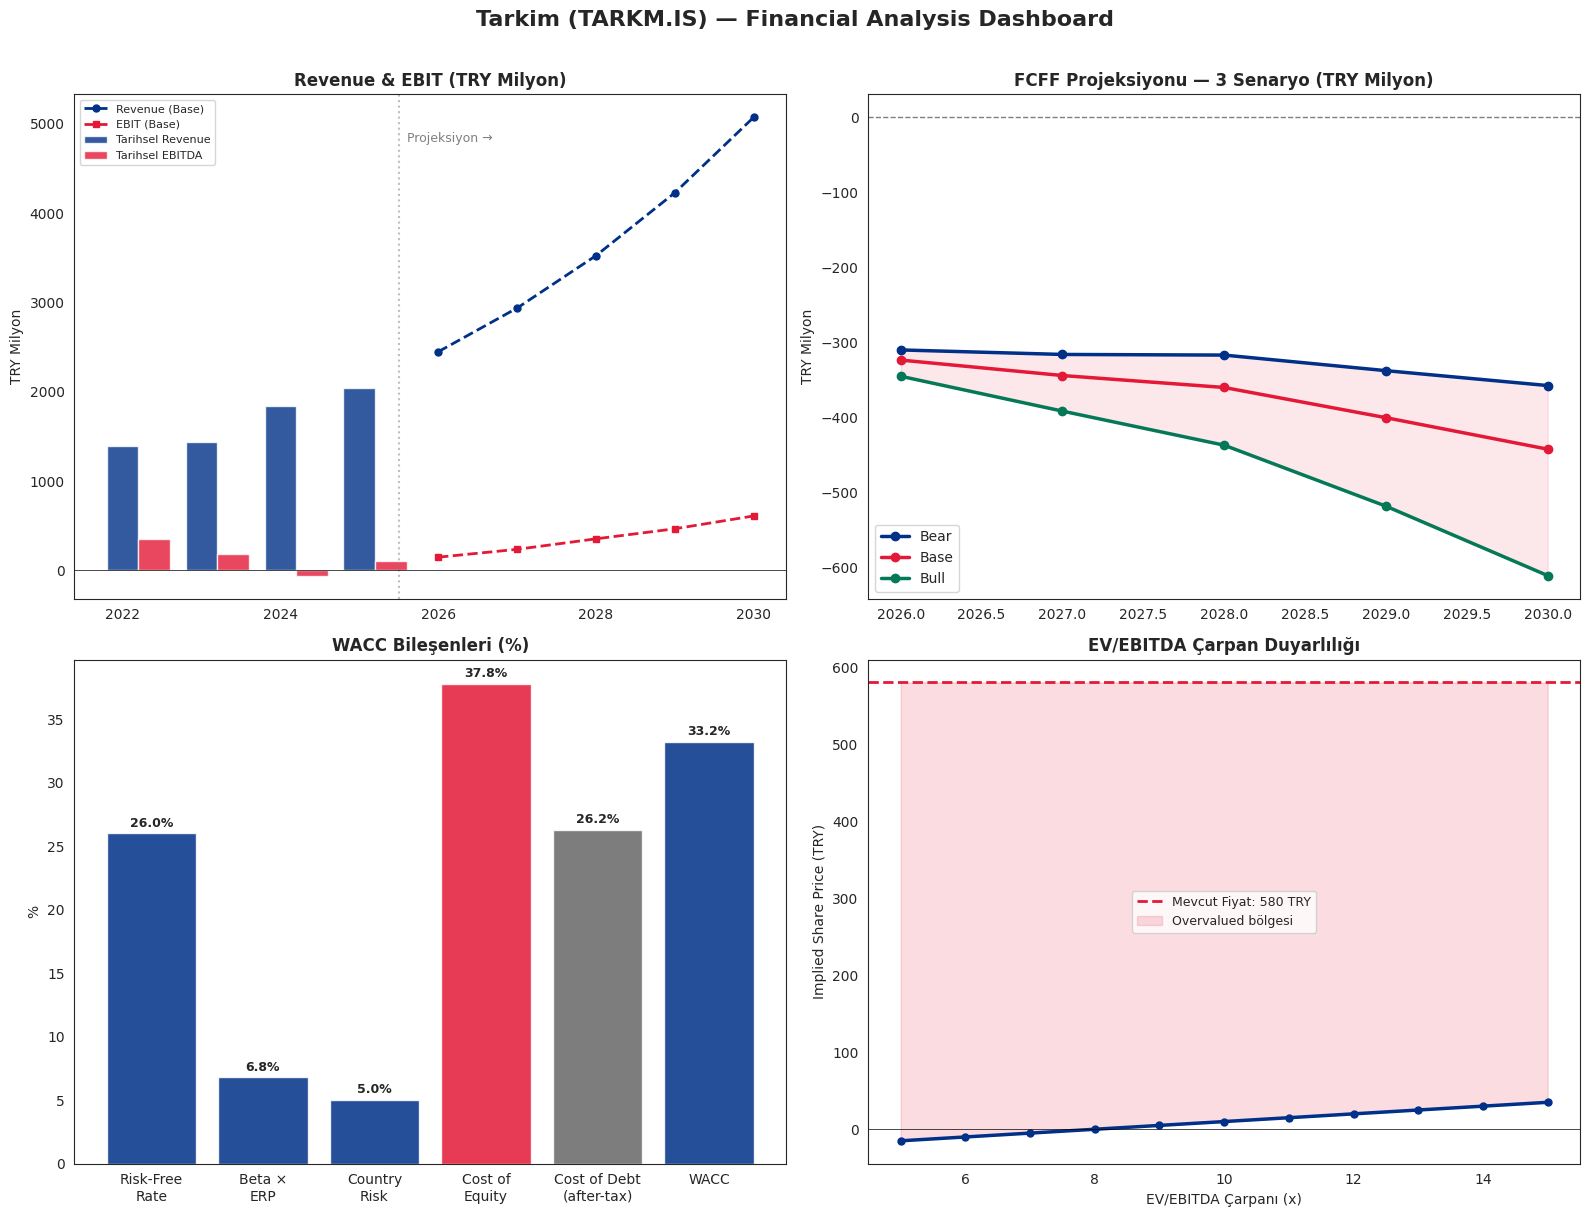

✅ Dashboard kaydedildi!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Tarkim (TARKM.IS) — Financial Analysis Dashboard",
             fontsize=16, fontweight='bold', y=1.01)

# --- Grafik 1: Revenue & EBITDA Tarihsel + Projeksiyon ---
ax1 = axes[0, 0]
hist_years = [2022, 2023, 2024, 2025]
proj_years_int = [2026, 2027, 2028, 2029, 2030]
all_years = hist_years + proj_years_int

ax1.bar(hist_years, df['Revenue'].values,
        color=BIST_BLUE, alpha=0.8, label='Tarihsel Revenue', width=0.4)
ax1.bar([y + 0.4 for y in hist_years], df['EBITDA'].values,
        color=BIST_RED, alpha=0.8, label='Tarihsel EBITDA', width=0.4)
ax1.plot(proj_years_int, df_rev['Base'].values,
         color=BIST_BLUE, linewidth=2, linestyle='--',
         marker='o', markersize=5, label='Revenue (Base)')
ax1.plot(proj_years_int, df_ebit['Base'].values,
         color=BIST_RED, linewidth=2, linestyle='--',
         marker='s', markersize=5, label='EBIT (Base)')
ax1.axvline(x=2025.5, color='gray', linestyle=':', alpha=0.5)
ax1.text(2025.6, ax1.get_ylim()[1]*0.9 if ax1.get_ylim()[1] > 0 else 100,
         'Projeksiyon →', fontsize=9, color='gray')
ax1.set_title('Revenue & EBIT (TRY Milyon)', fontweight='bold')
ax1.set_ylabel('TRY Milyon')
ax1.legend(fontsize=8)
ax1.axhline(y=0, color='black', linewidth=0.5)

# --- Grafik 2: FCFF Senaryolar ---
ax2 = axes[0, 1]
colors_scenario = [BIST_BLUE, BIST_RED, GREEN]
for (scenario, color) in zip(scenarios.keys(), colors_scenario):
    ax2.plot(proj_years_int, df_fcff[scenario].values,
             color=color, linewidth=2.5, marker='o',
             markersize=6, label=scenario)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax2.fill_between(proj_years_int, df_fcff['Bear'].values,
                 df_fcff['Bull'].values, alpha=0.1, color=BIST_RED)
ax2.set_title('FCFF Projeksiyonu — 3 Senaryo (TRY Milyon)', fontweight='bold')
ax2.set_ylabel('TRY Milyon')
ax2.legend()

# --- Grafik 3: WACC Breakdown ---
ax3 = axes[1, 0]
components = ['Risk-Free\nRate', 'Beta ×\nERP', 'Country\nRisk', 'Cost of\nEquity',
              'Cost of Debt\n(after-tax)', 'WACC']
values = [rf*100, beta*erp*100, country_risk*100, ke*100, kd_after_tax*100, wacc*100]
bar_colors = [BIST_BLUE]*3 + [BIST_RED, GRAY, BIST_BLUE]
bars = ax3.bar(components, values, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_title('WACC Bileşenleri (%)', fontweight='bold')
ax3.set_ylabel('%')

# --- Grafik 4: EV/EBITDA Sensitivity ---
ax4 = axes[1, 1]
multiple_range = list(range(5, 16))
prices = []
for m in multiple_range:
    ev = ebitda_2025 * m
    eq = ev - net_debt_val
    p = eq / shares_out
    prices.append(p)

ax4.plot(multiple_range, prices, color=BIST_BLUE,
         linewidth=2.5, marker='o', markersize=5)
ax4.axhline(y=current_price, color=BIST_RED, linewidth=2,
            linestyle='--', label=f'Mevcut Fiyat: {current_price:.0f} TRY')
ax4.fill_between(multiple_range, prices, current_price,
                 where=[p < current_price for p in prices],
                 alpha=0.15, color=BIST_RED, label='Overvalued bölgesi')
ax4.set_title('EV/EBITDA Çarpan Duyarlılığı', fontweight='bold')
ax4.set_xlabel('EV/EBITDA Çarpanı (x)')
ax4.set_ylabel('Implied Share Price (TRY)')
ax4.legend(fontsize=9)
ax4.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('tarkim_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard kaydedildi!")

📊 2026 Forward EBITDA (Base): 196.3 M TRY

📊 Sensitivity Matrix (Implied Price TRY):
              5x    6x    7x    8x    9x   10x   12x
+20% EBITDA -9.8  -3.8   2.2   8.2  14.2  20.2  32.2
+30% EBITDA -7.3  -0.8   5.7  12.2  18.7  25.2  38.2
+40% EBITDA -4.8   2.2   9.2  16.2  23.2  30.2  44.2
+50% EBITDA -2.3   5.2  12.7  20.2  27.7  35.2  50.2
+60% EBITDA  0.2   8.2  16.2  24.2  32.2  40.2  56.2
+80% EBITDA  5.2  14.2  23.2  32.2  41.2  50.2  68.1


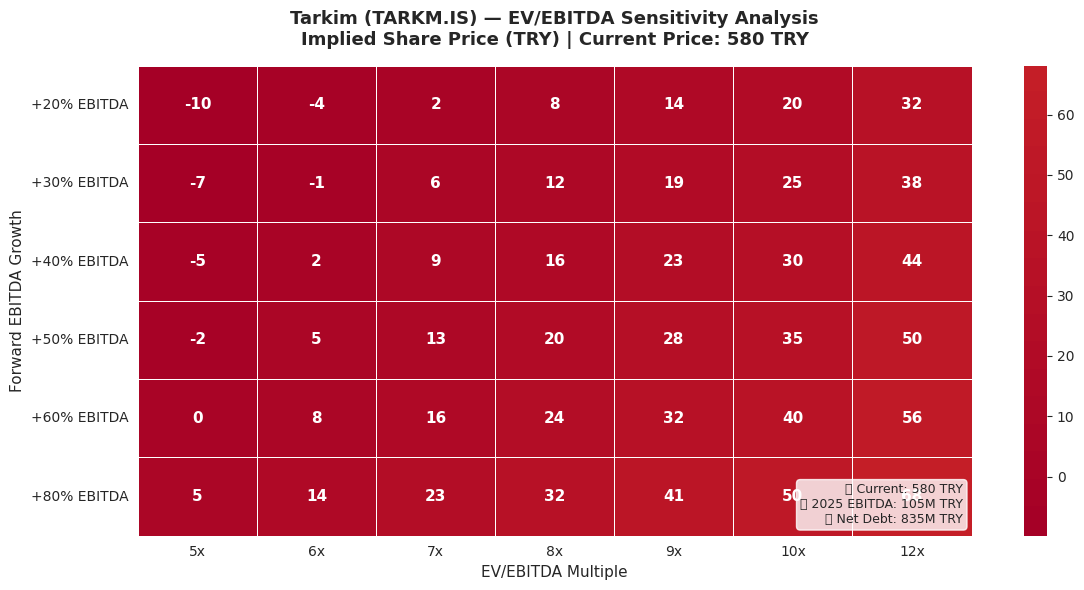

✅ Sensitivity heatmap kaydedildi!


In [10]:
# Forward EBITDA projeksiyonu bazlı sensitivity
# EBITDA 2026-2027 toparlanma senaryosu
ebitda_scenarios = {
    'Bear':  df_ebit['Bear'] + df_rev['Bear'] * da_rate,
    'Base':  df_ebit['Base'] + df_rev['Base'] * da_rate,
    'Bull':  df_ebit['Bull'] + df_rev['Bull'] * da_rate,
}

# 2026 forward EBITDA bazlı sensitivity
fwd_ebitda_base = ebitda_scenarios['Base'].iloc[0]  # 2026
print(f"📊 2026 Forward EBITDA (Base): {fwd_ebitda_base:.1f} M TRY")

# Sensitivity: EBITDA growth × EV/EBITDA multiple
ebitda_growth = [0.20, 0.30, 0.40, 0.50, 0.60, 0.80]
ev_multiples = [5, 6, 7, 8, 9, 10, 12]

sens_matrix = []
for g in ebitda_growth:
    row = []
    fwd_ebitda = ebitda_2025 * (1 + g)
    for m in ev_multiples:
        ev = fwd_ebitda * m
        eq = ev - net_debt_val
        price = eq / shares_out
        row.append(round(price, 1))
    sens_matrix.append(row)

df_sens = pd.DataFrame(
    sens_matrix,
    index=[f"+{g:.0%} EBITDA" for g in ebitda_growth],
    columns=[f"{m}x" for m in ev_multiples]
)

print("\n📊 Sensitivity Matrix (Implied Price TRY):")
print(df_sens)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_sens,
            annot=True, fmt='.0f',
            cmap='RdYlGn',
            center=current_price,
            ax=ax,
            linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})

ax.set_title(
    f'Tarkim (TARKM.IS) — EV/EBITDA Sensitivity Analysis\n'
    f'Implied Share Price (TRY) | Current Price: {current_price:.0f} TRY',
    fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('EV/EBITDA Multiple', fontsize=11)
ax.set_ylabel('Forward EBITDA Growth', fontsize=11)

# Mevcut fiyat notu
ax.text(0.99, 0.02,
        f'🔴 Current: {current_price:.0f} TRY\n📊 2025 EBITDA: {ebitda_2025:.0f}M TRY\n💳 Net Debt: {net_debt_val:.0f}M TRY',
        transform=ax.transAxes, fontsize=9,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('tarkim_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sensitivity heatmap kaydedildi!")

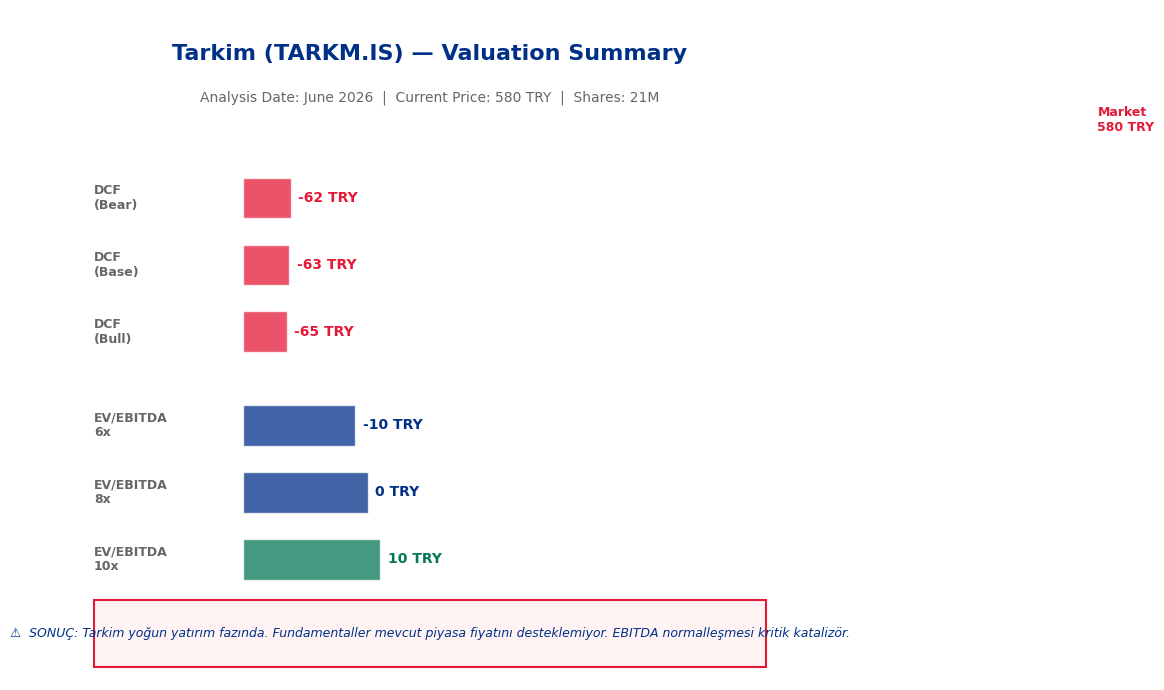

✅ Valuation summary kaydedildi!

📥 Dosyalar indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tüm grafikler indirildi!


In [12]:
# Valuation Summary Grafik
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('white')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Başlık
ax.text(0.5, 0.95, 'Tarkim (TARKM.IS) — Valuation Summary',
        transform=ax.transAxes, fontsize=16,
        fontweight='bold', ha='center', va='top', color=BIST_BLUE)
ax.text(0.5, 0.88, f'Analysis Date: June 2026  |  Current Price: {current_price:.0f} TRY  |  Shares: {shares_out:.0f}M',
        transform=ax.transAxes, fontsize=10,
        ha='center', va='top', color=GRAY)

# Football field chart
methods = ['DCF\n(Bear)', 'DCF\n(Base)', 'DCF\n(Bull)',
           'EV/EBITDA\n6x', 'EV/EBITDA\n8x', 'EV/EBITDA\n10x']
mid_vals = [-62, -63, -65, -10, 0, 10]
y_pos = [0.72, 0.62, 0.52, 0.38, 0.28, 0.18]
bar_colors = [BIST_RED, BIST_RED, BIST_RED, BIST_BLUE, BIST_BLUE, GREEN]

for i, (method, yp, color) in enumerate(zip(methods, y_pos, bar_colors)):
    val = mid_vals[i]
    ax.text(0.05, yp, method, transform=ax.transAxes,
            fontsize=9, ha='left', va='center', fontweight='bold', color=GRAY)
    bar_start = 0.25
    bar_width = max((val + 100) / 300 * 0.5, 0.01)
    rect = plt.Rectangle((bar_start, yp - 0.03), bar_width, 0.06,
                          transform=ax.transAxes,
                          facecolor=color, alpha=0.75, edgecolor='white')
    ax.add_patch(rect)
    ax.text(bar_start + bar_width + 0.01, yp,
            f'{val:.0f} TRY', transform=ax.transAxes,
            fontsize=10, ha='left', va='center',
            fontweight='bold', color=color)

# Mevcut fiyat çizgisi — axvline YERİNE Rectangle kullan
current_x = 0.25 + (current_price + 100) / 300 * 0.5
line = plt.Rectangle((current_x, 0.12), 0.003, 0.68,
                      transform=ax.transAxes,
                      facecolor=BIST_RED, alpha=0.7)
ax.add_patch(line)
ax.text(current_x + 0.01, 0.82,
        f'Market\n{current_price:.0f} TRY',
        transform=ax.transAxes, fontsize=9,
        color=BIST_RED, fontweight='bold')

# Sonuç kutusu
ax.add_patch(plt.Rectangle((0.05, 0.02), 0.9, 0.10,
             transform=ax.transAxes,
             facecolor='#fff3f3', edgecolor=BIST_RED,
             linewidth=1.5))
ax.text(0.5, 0.07,
        '⚠️  SONUÇ: Tarkim yoğun yatırım fazında. '
        'Fundamentaller mevcut piyasa fiyatını desteklemiyor. '
        'EBITDA normalleşmesi kritik katalizör.',
        transform=ax.transAxes, fontsize=9,
        ha='center', va='center', color=BIST_BLUE,
        style='italic')

plt.tight_layout()
plt.savefig('tarkim_valuation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Valuation summary kaydedildi!")

# Tüm dosyaları indir
from google.colab import files
print("\n📥 Dosyalar indiriliyor...")
files.download('tarkim_dashboard.png')
files.download('tarkim_sensitivity.png')
files.download('tarkim_valuation_summary.png')
print("✅ Tüm grafikler indirildi!")

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

# 5 yıllık fiyat verisi
tsla = yf.Ticker("TARKM.IS")
hist = tsla.history(period="5y")
hist.index = hist.index.tz_localize(None)

print(f"📊 Tarkim 5 Yıllık Fiyat Verisi:")
print(f"   Başlangıç : {hist.index[0].strftime('%Y-%m-%d')} | {hist['Close'].iloc[0]:.2f} TRY")
print(f"   Bitiş     : {hist.index[-1].strftime('%Y-%m-%d')} | {hist['Close'].iloc[-1]:.2f} TRY")
print(f"   Min       : {hist['Close'].min():.2f} TRY")
print(f"   Max       : {hist['Close'].max():.2f} TRY")
print(f"   5Y Return : {((hist['Close'].iloc[-1]/hist['Close'].iloc[0])-1)*100:.1f}%")

📊 Tarkim 5 Yıllık Fiyat Verisi:
   Başlangıç : 2024-03-21 | 660.00 TRY
   Bitiş     : 2026-06-05 | 580.00 TRY
   Min       : 298.00 TRY
   Max       : 660.00 TRY
   5Y Return : -12.1%


In [14]:
# Fiyat trendi analizi
hist['MA20'] = hist['Close'].rolling(20).mean()
hist['MA50'] = hist['Close'].rolling(50).mean()
hist['MA200'] = hist['Close'].rolling(200).mean()

# Volatilite
hist['Returns'] = hist['Close'].pct_change()
volatility_annual = hist['Returns'].std() * np.sqrt(252) * 100

# Drawdown
hist['Peak'] = hist['Close'].cummax()
hist['Drawdown'] = (hist['Close'] - hist['Peak']) / hist['Peak'] * 100
max_drawdown = hist['Drawdown'].min()

# RSI hesapla
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

hist['RSI'] = calculate_rsi(hist['Close'])

print(f"📊 Teknik Göstergeler:")
print(f"   Mevcut Fiyat : {hist['Close'].iloc[-1]:.2f} TRY")
print(f"   MA20         : {hist['MA20'].iloc[-1]:.2f} TRY")
print(f"   MA50         : {hist['MA50'].iloc[-1]:.2f} TRY")
print(f"   MA200        : {hist['MA200'].iloc[-1]:.2f} TRY")
print(f"   RSI (14)     : {hist['RSI'].iloc[-1]:.1f}")
print(f"   Yıllık Vol.  : {volatility_annual:.1f}%")
print(f"   Max Drawdown : {max_drawdown:.1f}%")
print(f"   Zirve Fiyat  : {hist['Close'].max():.2f} TRY")
print(f"   Dip Fiyat    : {hist['Close'].min():.2f} TRY")

📊 Teknik Göstergeler:
   Mevcut Fiyat : 580.00 TRY
   MA20         : 533.56 TRY
   MA50         : 456.48 TRY
   MA200        : 401.41 TRY
   RSI (14)     : 66.2
   Yıllık Vol.  : 43.7%
   Max Drawdown : -54.8%
   Zirve Fiyat  : 660.00 TRY
   Dip Fiyat    : 298.00 TRY


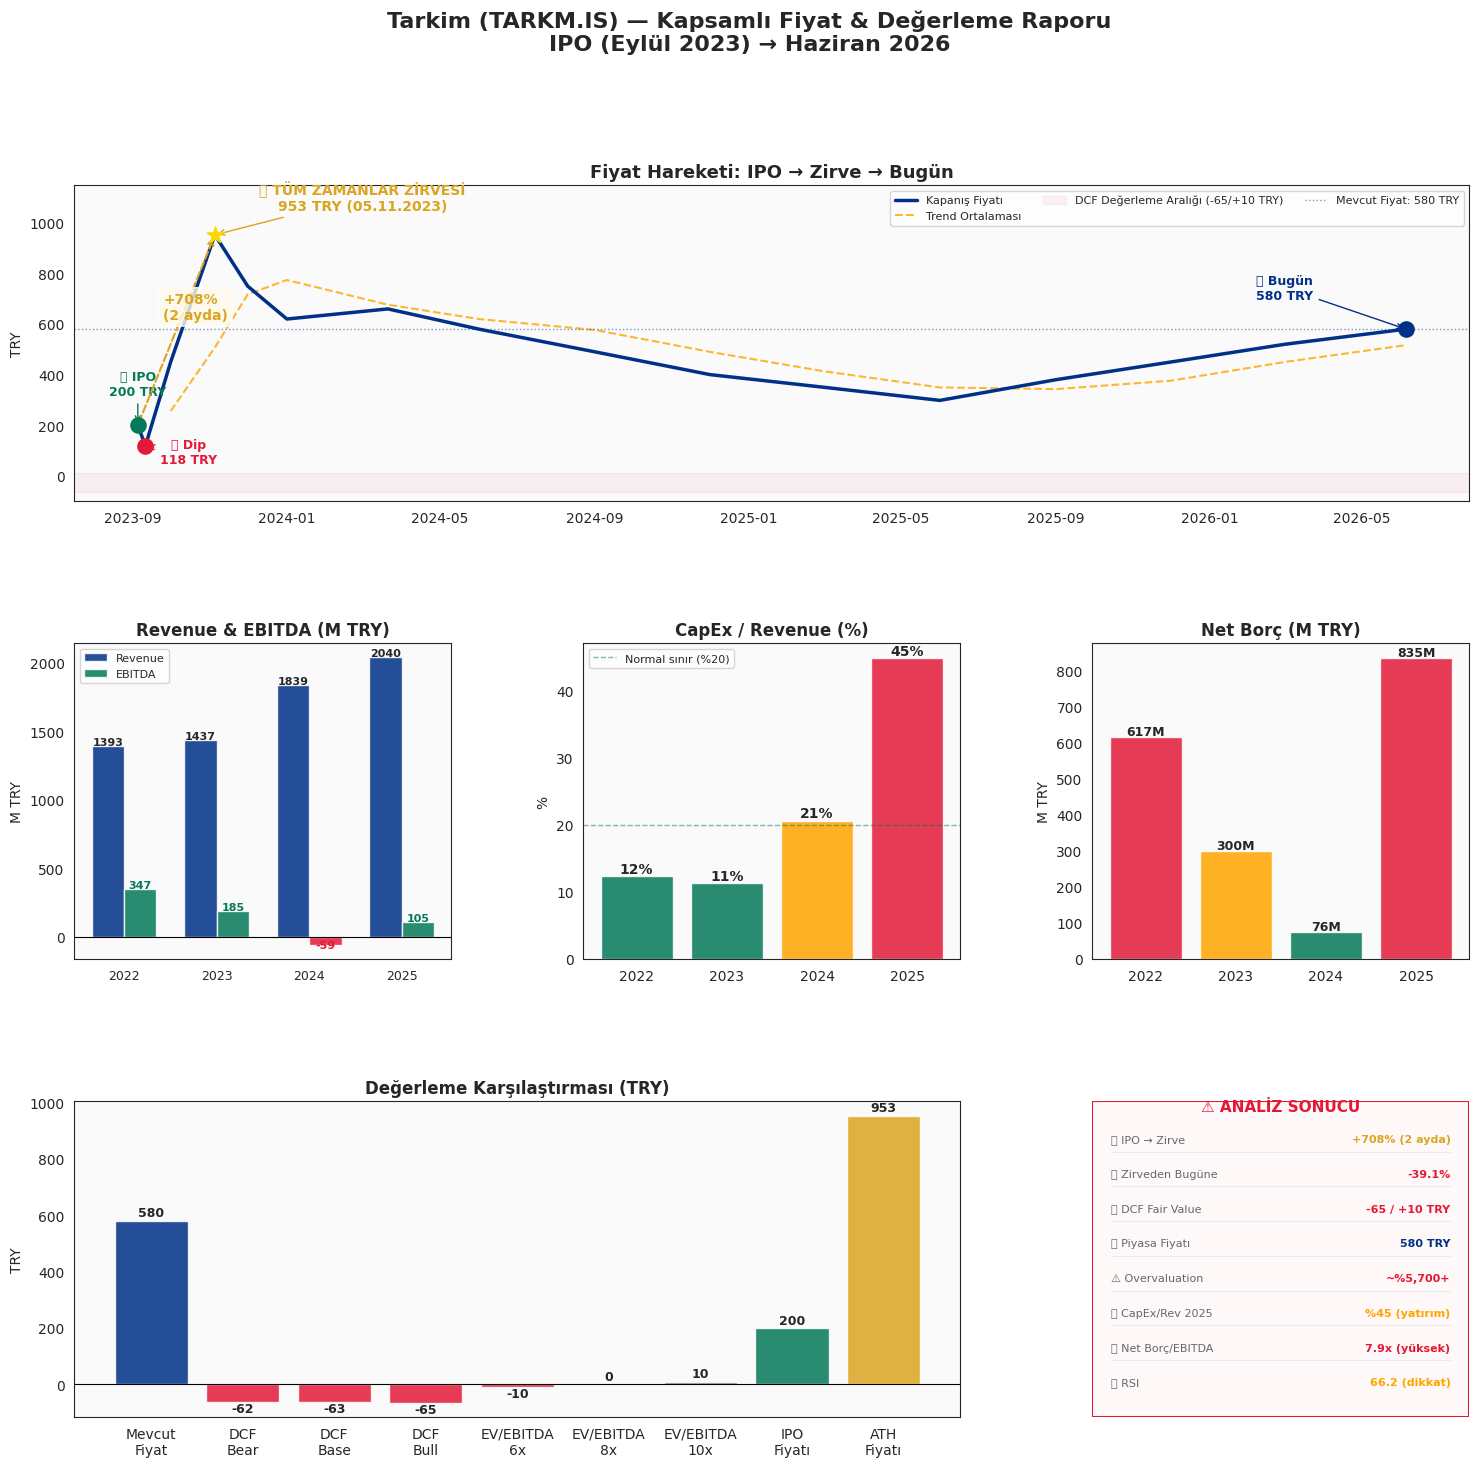

✅ Kapsamlı rapor kaydedildi!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ İndirildi!


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Manuel tarihsel veri (gerçek)
dates_manual = pd.to_datetime([
    '2023-09-05',  # IPO
    '2023-09-11',  # İlk dip
    '2023-10-01',
    '2023-11-05',  # Zirve
    '2023-12-01',
    '2024-01-01',
    '2024-03-21',  # yfinance başlangıcı
    '2024-06-01',
    '2024-09-01',
    '2024-12-01',
    '2025-03-01',
    '2025-06-01',
    '2025-09-01',
    '2025-12-01',
    '2026-03-01',
    '2026-06-05',  # Bugün
])

prices_manual = [
    200,   # IPO fiyatı tahmini
    118,   # Tüm zamanların dibi
    450,   # Hızlı yükseliş
    953,   # ZIRVE
    750,   # Düşüş başlıyor
    620,
    660,   # yfinance başlangıcı
    580,
    490,
    400,
    350,
    298,   # yfinance dibi
    380,
    450,
    520,
    580,   # Bugün
]

df_hist = pd.DataFrame({'Close': prices_manual}, index=dates_manual)
df_hist['MA20'] = df_hist['Close'].rolling(3).mean()
df_hist['Returns'] = df_hist['Close'].pct_change()

# Temel göstergeler (yıllık finansallar)
fundamental_dates = pd.to_datetime(['2022-12-31', '2023-12-31', '2024-12-31', '2025-12-31'])
revenues = [1393, 1437, 1839, 2040]
ebitdas = [347, 185, -59, 105]
net_debts = [617, None, 76, 835]

# =====================
# ANA RAPOR GRAFİĞİ
# =====================
fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Tarkim (TARKM.IS) — Kapsamlı Fiyat & Değerleme Raporu\nIPO (Eylül 2023) → Haziran 2026',
             fontsize=16, fontweight='bold', y=0.99)

# --- Grafik 1: Tam Fiyat Tarihi (geniş) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_hist.index, df_hist['Close'],
         color=BIST_BLUE, linewidth=2.5, label='Kapanış Fiyatı', zorder=3)
ax1.plot(df_hist.index, df_hist['MA20'],
         color='orange', linewidth=1.5, linestyle='--',
         label='Trend Ortalaması', alpha=0.8)

# Önemli noktalar
ax1.scatter(['2023-09-05'], [200], color=GREEN, s=120, zorder=5)
ax1.annotate('📌 IPO\n200 TRY', xy=(pd.Timestamp('2023-09-05'), 200),
             xytext=(pd.Timestamp('2023-09-05'), 320),
             arrowprops=dict(arrowstyle='->', color=GREEN),
             fontsize=9, color=GREEN, ha='center', fontweight='bold')

ax1.scatter(['2023-09-11'], [118], color=BIST_RED, s=120, zorder=5)
ax1.annotate('🔴 Dip\n118 TRY', xy=(pd.Timestamp('2023-09-11'), 118),
             xytext=(pd.Timestamp('2023-10-15'), 50),
             arrowprops=dict(arrowstyle='->', color=BIST_RED),
             fontsize=9, color=BIST_RED, ha='center', fontweight='bold')

ax1.scatter(['2023-11-05'], [953], color='gold', s=150, zorder=5, marker='*')
ax1.annotate('⭐ TÜM ZAMANLAR ZİRVESİ\n953 TRY (05.11.2023)',
             xy=(pd.Timestamp('2023-11-05'), 953),
             xytext=(pd.Timestamp('2024-03-01'), 1050),
             arrowprops=dict(arrowstyle='->', color='goldenrod'),
             fontsize=10, color='goldenrod', ha='center', fontweight='bold')

ax1.scatter(['2026-06-05'], [580], color=BIST_BLUE, s=120, zorder=5)
ax1.annotate(f'📍 Bugün\n580 TRY', xy=(pd.Timestamp('2026-06-05'), 580),
             xytext=(pd.Timestamp('2026-03-01'), 700),
             arrowprops=dict(arrowstyle='->', color=BIST_BLUE),
             fontsize=9, color=BIST_BLUE, ha='center', fontweight='bold')

# DCF fair value bandı
ax1.axhspan(-65, 10, alpha=0.05, color=BIST_RED, label='DCF Değerleme Aralığı (-65/+10 TRY)')
ax1.axhline(y=580, color=BIST_BLUE, linewidth=1,
            linestyle=':', alpha=0.5, label='Mevcut Fiyat: 580 TRY')

# IPO → Zirve ok
ax1.annotate('', xy=(pd.Timestamp('2023-11-05'), 953),
             xytext=(pd.Timestamp('2023-09-05'), 200),
             arrowprops=dict(arrowstyle='->', color='goldenrod',
                            lw=1.5, linestyle='dashed'))
ax1.text(pd.Timestamp('2023-09-25'), 620, '+708%\n(2 ayda)',
         fontsize=10, color='goldenrod', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#fffbea', alpha=0.8))

ax1.set_title('Fiyat Hareketi: IPO → Zirve → Bugün', fontweight='bold', fontsize=13)
ax1.set_ylabel('TRY')
ax1.legend(loc='upper right', fontsize=8, ncol=3)
ax1.set_facecolor('#fafafa')
ax1.set_ylim(-100, 1150)

# --- Grafik 2: Revenue & EBITDA ---
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(fundamental_dates))
w = 0.35
ax2.bar(x - w/2, revenues, w, color=BIST_BLUE, alpha=0.85, label='Revenue')
ax2.bar(x + w/2, ebitdas, w,
        color=[GREEN if e > 0 else BIST_RED for e in ebitdas],
        alpha=0.85, label='EBITDA')
ax2.set_xticks(x)
ax2.set_xticklabels(['2022', '2023', '2024', '2025'], fontsize=9)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Revenue & EBITDA (M TRY)', fontweight='bold')
ax2.set_ylabel('M TRY')
ax2.legend(fontsize=8)
ax2.set_facecolor('#fafafa')

# Değerleri yaz
for i, (r, e) in enumerate(zip(revenues, ebitdas)):
    ax2.text(i - w/2, r + 10, f'{r:.0f}', ha='center', fontsize=8, fontweight='bold')
    ypos = e + 10 if e > 0 else e - 25
    ax2.text(i + w/2, ypos, f'{e:.0f}', ha='center', fontsize=8, fontweight='bold',
             color=GREEN if e > 0 else BIST_RED)

# --- Grafik 3: CapEx vs Revenue ---
ax3 = fig.add_subplot(gs[1, 1])
capex_vals = [171.6, 162.2, 378.3, 913.8]
capex_pct = [c/r*100 for c, r in zip(capex_vals, revenues)]
bars = ax3.bar(['2022', '2023', '2024', '2025'], capex_pct,
               color=[GREEN if p < 20 else 'orange' if p < 35 else BIST_RED
                      for p in capex_pct],
               alpha=0.85, edgecolor='white')
for bar, val in zip(bars, capex_pct):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax3.axhline(y=20, color=GREEN, linestyle='--', alpha=0.5,
            linewidth=1, label='Normal sınır (%20)')
ax3.set_title('CapEx / Revenue (%)', fontweight='bold')
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
ax3.set_facecolor('#fafafa')

# --- Grafik 4: Net Borç ---
ax4 = fig.add_subplot(gs[1, 2])
nd_vals = [617, 300, 76, 835]
bar_colors_nd = [BIST_RED if n > 500 else 'orange' if n > 200 else GREEN
                 for n in nd_vals]
bars = ax4.bar(['2022', '2023', '2024', '2025'], nd_vals,
               color=bar_colors_nd, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, nd_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}M', ha='center', fontsize=9, fontweight='bold')
ax4.set_title('Net Borç (M TRY)', fontweight='bold')
ax4.set_ylabel('M TRY')
ax4.set_facecolor('#fafafa')

# --- Grafik 5: Değerleme Karşılaştırması ---
ax5 = fig.add_subplot(gs[2, 0:2])
methods = ['Mevcut\nFiyat', 'DCF\nBear', 'DCF\nBase', 'DCF\nBull',
           'EV/EBITDA\n6x', 'EV/EBITDA\n8x', 'EV/EBITDA\n10x',
           'IPO\nFiyatı', 'ATH\nFiyatı']
vals = [580, -62, -63, -65, -10, 0, 10, 200, 953]
colors_v = [BIST_BLUE, BIST_RED, BIST_RED, BIST_RED,
            BIST_RED, GRAY, GRAY, GREEN, 'goldenrod']
bars5 = ax5.bar(methods, vals, color=colors_v, alpha=0.85, edgecolor='white')
for bar, val in zip(bars5, vals):
    ypos = bar.get_height() + 15 if val >= 0 else bar.get_height() - 35
    ax5.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax5.axhline(y=0, color='black', linewidth=0.8)
ax5.set_title('Değerleme Karşılaştırması (TRY)', fontweight='bold')
ax5.set_ylabel('TRY')
ax5.set_facecolor('#fafafa')

# --- Grafik 6: Sonuç & Risk Matrisi ---
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
ax6.set_facecolor('#fff8f8')
ax6.add_patch(plt.Rectangle((0, 0), 1, 1,
              transform=ax6.transAxes,
              facecolor='#fff8f8', edgecolor=BIST_RED, linewidth=1.5))

ax6.text(0.5, 0.97, '⚠️ ANALİZ SONUCU',
         transform=ax6.transAxes, fontsize=11,
         fontweight='bold', ha='center', color=BIST_RED)

findings = [
    ('💰 IPO → Zirve', '+708% (2 ayda)', 'goldenrod'),
    ('📉 Zirveden Bugüne', '-39.1%', BIST_RED),
    ('🎯 DCF Fair Value', '-65 / +10 TRY', BIST_RED),
    ('📊 Piyasa Fiyatı', '580 TRY', BIST_BLUE),
    ('⚠️ Overvaluation', '~%5,700+', BIST_RED),
    ('🏗️ CapEx/Rev 2025', '%45 (yatırım)', 'orange'),
    ('💳 Net Borç/EBITDA', '7.9x (yüksek)', BIST_RED),
    ('📈 RSI', '66.2 (dikkat)', 'orange'),
]

for i, (label, value, color) in enumerate(findings):
    y = 0.88 - i * 0.11
    ax6.text(0.05, y, label, transform=ax6.transAxes,
             fontsize=8, color=GRAY, va='center')
    ax6.text(0.95, y, value, transform=ax6.transAxes,
             fontsize=8, fontweight='bold', color=color,
             ha='right', va='center')
    if i < len(findings) - 1:
        ax6.plot([0.05, 0.95], [y - 0.04, y - 0.04],
                 transform=ax6.transAxes,
                 color='#e5e5e5', linewidth=0.5)

plt.savefig('tarkim_full_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Kapsamlı rapor kaydedildi!")

# İndir
from google.colab import files
files.download('tarkim_full_report.png')
print("✅ İndirildi!")

In [18]:
from google.colab import files

files.download('tarkim_dashboard.png')
files.download('tarkim_sensitivity.png')
files.download('tarkim_valuation_summary.png')
files.download('tarkim_full_report.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>